In [1]:
import pandas as pd
from shapely import wkt
import geopandas as gpd
from shapely import wkt
import subprocess, os
import numpy as np
import altair as alt
import datetime



os.environ["JAVA_HOME"] = subprocess.run(
    ["/usr/libexec/java_home", "-v", "21"],
    capture_output=True, text=True, check=True
).stdout.strip()


import r5py
import warnings
warnings.filterwarnings("ignore")

In [2]:
neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)
neigh = neigh[["name", "geometry"]]
neigh["geometry"] = neigh.buffer(0)


neigh_layer = alt.Chart(neigh).mark_geoshape(
    stroke="black",
    fill="lightblue"
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

In [3]:
bus_sol = pd.read_csv('Nodes/Bus-Sol.csv')
bus = pd.read_csv('Nodes/Bus.csv')
fgc_sol = pd.read_csv('Nodes/FGC-Sol.csv')
fgc = pd.read_csv('Nodes/FGC.csv')
metro_sol = pd.read_csv('Nodes/Metro-Sol.csv')
metro = pd.read_csv('Nodes/Metro.csv')
tram_sol = pd.read_csv('Nodes/Tram-Sol.csv')
tram = pd.read_csv('Nodes/Tram.csv')
destinations = pd.read_csv('Nodes/Destinations.csv')

all_stops = pd.concat([bus_sol, bus, fgc_sol, fgc, metro_sol, metro, tram_sol, tram], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


In [4]:
metro_sol = pd.read_csv('Nodes/Tram-Sol.csv')
metro = pd.read_csv('Nodes/Tram.csv')

all_stops = pd.concat([metro_sol, metro], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


In [5]:
# netejhar cache si cambiem el transport_network
import shutil
from r5py.util.config import Config
cache_dir = Config().CACHE_DIR
for f in cache_dir.glob("*.mapdb*"):
    f.unlink()
print(f"Cleared cache in {cache_dir}")

Cleared cache in /Users/bmantepe/.cache/r5py


In [6]:
transport_network = r5py.TransportNetwork(
    "Data/Neigh/cataluna-260811.osm.pbf",
    elevation_model =["Data/Neigh/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1786456535055.tif"]
    )

In [7]:
import datetime

isocores_df = pd.DataFrame()
process = 0
for stop in all_stops['stop_id'].unique(): 
    process += 1
    if stop !=  'PIUS' and stop != 'PLRL':
        continue
    print(f"Processing stop {process}/{len(all_stops['stop_id'].unique())}")
    stop_row = all_stops[all_stops['stop_id'] == stop]
    stop_row.drop_duplicates(inplace=True,subset=['stop_id'], keep='first')

    isochrones = r5py.Isochrones(
        transport_network,
        origins=stop_row,
        transport_modes=[r5py.TransportMode.WALK],
        snap_to_network=True,
        isochrones = [5],
        point_grid_resolution=35,


    )
    isochrones['stop_id'] = stop
    #isochrones["geometry"] = isochrones.geometry.polygonize()
    isocores_df = pd.concat([isocores_df, isochrones], ignore_index=True)

isocores_df.drop(columns=['travel_time'], inplace=True)


Processing stop 5/44
Processing stop 6/44


In [8]:
isocores_df

,geometry,stop_id
0,"MULTILINESTRING ((2.11952 41.38703, 2.11945 41...",PIUS
1,"MULTILINESTRING ((2.11585 41.38639, 2.11578 41...",PLRL


<Axes: >

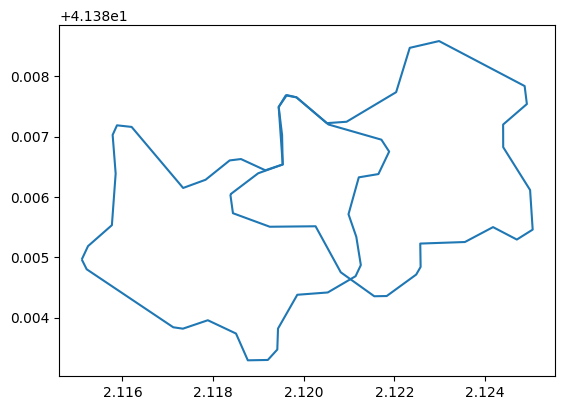

In [9]:
isocores_df.plot()

In [146]:
isocores_df['stop_id'].unique()

array(['FRMC', 'ILLA', 'NMNC', 'MRCR', 'PIUS', 'PLRL', 'UNIV', 'XILE',
       'LLUC', 'SRMN', 'OLIV', 'CLOT', 'PTSP', 'SRDN', 'MNTS', 'PDRO',
       'IIGL', 'CNLL', 'AIGU', 'FTJO', 'BVIA', 'CTMP', 'FSTA', 'BDOR',
       'HTV3', 'RBSJ', 'WLDN', 'TRBL', 'CCML', 'DGMR', 'FRUM', 'CDBE',
       'PORT', 'SABS', 'STMR', 'BSOS', 'ALFS', 'PARC', 'CTLN', 'STJB',
       'NKNS', 'STRC', 'GORG', 'MINA'], dtype=object)

In [10]:
isocores_df.to_crs('EPSG:4326', inplace=True)
all_stops.to_crs('EPSG:4326', inplace=True)


isos = alt.Chart(isocores_df[isocores_df['stop_id'].isin(['PLRL', 'PIUS'])]).mark_geoshape(
    filled=True,
    opacity=0.5,
).encode(
    color=alt.Color('stop_id:N')
)

points = alt.Chart(all_stops[all_stops['stop_id'].isin(['PLRL', 'PIUS'])]).mark_geoshape(
    filled=True,
    size=0,
).encode(
    tooltip=['stop_id:N']
)

isos + points

alt.LayerChart(...)

In [22]:
isocores_df.to_crs('EPSG:4326', inplace=True)
all_stops.to_crs('EPSG:4326', inplace=True)

projection = alt.Projection(type='mercator', center=[2.11846, 41.38592], scale=1200000)

isos = alt.Chart(isocores_df[isocores_df['stop_id'].isin(['PLRL', 'PIUS'])]).mark_geoshape(
    filled=True,
    opacity=0.5,
).encode(
    color=alt.Color('stop_id:N')
).project(
    type='mercator',
    center=[2.11846, 41.38592],
    scale=1200000,
)

points = alt.Chart(all_stops[all_stops['stop_id'].isin(['PLRL', 'PIUS'])]).mark_geoshape(
    filled=True,
    size=0,
).encode(
    tooltip=['stop_id:N']
).project(
    type='mercator',
    center=[2.11846, 41.38592],
    scale=1200000,
)

(neigh_layer + isos + points).project(
    type='mercator',
    center=[2.11846, 41.38592],
    scale=1200000,
)


alt.LayerChart(...)

In [176]:
isocores_df_all = all_stops[all_stops['stop_id'].isin(isocores_df['stop_id'].unique())].merge(isocores_df, on='stop_id', how='left')
isocores_df_all.drop(columns=['geometry_x'], inplace=True)
isocores_df_all.rename(columns={'geometry_y': 'geometry'}, inplace=True)
isocores_df_all.set_geometry('geometry', inplace=True)
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,ST-FRMC,FRMC,Francesc Macià,IU Stop,Tram,"POLYGON ((2.14141 41.39163, 2.14162 41.39291, ..."
1,ST-ILLA,ILLA,L'Illa,IU Stop,Tram,"POLYGON ((2.13451 41.38972, 2.13438 41.38988, ..."
2,ST-NMNC,NMNC,Numància,IU Stop,Tram,"POLYGON ((2.13103 41.38814, 2.13093 41.38827, ..."
3,ST-MRCR,MRCR,Maria Cristina,IU Stop,Tram,"POLYGON ((2.12567 41.38733, 2.12402 41.38655, ..."
4,ST-PIUS,PIUS,Pius XII,IU Stop,Tram,"POLYGON ((2.12256 41.38576, 2.12243 41.38573, ..."
...,...,...,...,...,...,...
125,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22389 41.42781, 2.22221 41.42702, ..."
126,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.22183 41.43047, 2.22171 41.43214, ..."
127,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22534 41.43499, 2.22532 41.43653, ..."
128,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.23283 41.43957, 2.23103 41.43872, ..."


In [177]:
test = all_stops.copy()

In [183]:
test.to_crs('EPSG:25831', inplace=True)
isocores_df_all.to_crs('EPSG:25831', inplace=True)
test.rename(columns={'id': 'destination_id','stop_id':'destination_stop_id','name':'destination_stop_name','linia':'destination_linia','stop_type':'destination_stop_type'}, inplace=True)
isocores_df_all.rename(columns={'id': 'origin_id','stop_id':'origin_stop_id','name':'origin_stop_name','linia':'origin_linia','stop_type':'origin_stop_type'}, inplace=True)
close_stops = gpd.sjoin(test[test['destination_id'].isin(isocores_df_all['origin_id'])], isocores_df_all, how='inner', predicate='within')
close_stops = close_stops[close_stops['origin_id'] != close_stops['destination_id']]
close_stops = close_stops[~close_stops['destination_id'].str.startswith('S')]
close_stops = close_stops[['origin_id', 'origin_stop_id', 'origin_stop_type', 'origin_stop_name', 'origin_linia', 'destination_id', 'destination_stop_id', 'destination_stop_type', 'destination_stop_name', 'destination_linia']]
close_stops['tram'] = close_stops['origin_stop_name'] + ' - ' + close_stops['destination_stop_name']
close_stops['mode'] = close_stops['origin_stop_type'] + ' - ' + close_stops['destination_stop_type']
close_stops['lines'] = close_stops['origin_linia'] + ' - ' + close_stops['destination_linia']
close_stops.drop(columns=['origin_stop_name', 'destination_stop_name','origin_stop_type','destination_stop_type','origin_linia','destination_linia'], inplace=True)
close_stops

,origin_id,origin_stop_id,destination_id,destination_stop_id,tram,mode,lines
44,ST-FRMC,FRMC,T-T1-FRMC,FRMC,Francesc Macià - Francesc Macià,Tram - Tram,IU Stop - T1
44,T-T2-FRMC,FRMC,T-T1-FRMC,FRMC,Francesc Macià - Francesc Macià,Tram - Tram,T2 - T1
44,T-T3-FRMC,FRMC,T-T1-FRMC,FRMC,Francesc Macià - Francesc Macià,Tram - Tram,T3 - T1
45,ST-FRMC,FRMC,T-T2-FRMC,FRMC,Francesc Macià - Francesc Macià,Tram - Tram,IU Stop - T2
45,T-T1-FRMC,FRMC,T-T2-FRMC,FRMC,Francesc Macià - Francesc Macià,Tram - Tram,T1 - T2
...,...,...,...,...,...,...,...
125,ST-STJB,STJB,T-T5-STJB,STJB,Sant Joan Baptista - Sant Joan Baptista,Tram - Tram,IU Stop - T5
126,ST-NKNS,NKNS,T-T5-NKNS,NKNS,Encants de Sant Adrià - Encants de Sant Adrià,Tram - Tram,IU Stop - T5
127,ST-STRC,STRC,T-T5-STRC,STRC,Sant Roc - Sant Roc,Tram - Tram,IU Stop - T5
128,ST-GORG,GORG,T-T5-GORG,GORG,Gorg - Gorg,Tram - Tram,IU Stop - T5


In [184]:
same_stops = close_stops[
    close_stops['origin_stop_id'] == close_stops['destination_stop_id']
].copy()
same_stops = same_stops.drop(columns=['origin_stop_id', 'destination_stop_id'])

conditions = [
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('T', na=False),
    same_stops['origin_id'].str.startswith('B', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith('M', na=False) & same_stops['destination_id'].str.startswith('M', na=False),
    same_stops['origin_id'].str.startswith('T', na=False) & same_stops['destination_id'].str.startswith('T', na=False),
]
choices = [3, 1, 2, 1, 2, 1]

same_stops['exchange_time'] = np.select(conditions, choices, default=0)
same_stops


,origin_id,destination_id,tram,mode,lines,exchange_time
44,ST-FRMC,T-T1-FRMC,Francesc Macià - Francesc Macià,Tram - Tram,IU Stop - T1,2
44,T-T2-FRMC,T-T1-FRMC,Francesc Macià - Francesc Macià,Tram - Tram,T2 - T1,1
44,T-T3-FRMC,T-T1-FRMC,Francesc Macià - Francesc Macià,Tram - Tram,T3 - T1,1
45,ST-FRMC,T-T2-FRMC,Francesc Macià - Francesc Macià,Tram - Tram,IU Stop - T2,2
45,T-T1-FRMC,T-T2-FRMC,Francesc Macià - Francesc Macià,Tram - Tram,T1 - T2,1
...,...,...,...,...,...,...
125,ST-STJB,T-T5-STJB,Sant Joan Baptista - Sant Joan Baptista,Tram - Tram,IU Stop - T5,2
126,ST-NKNS,T-T5-NKNS,Encants de Sant Adrià - Encants de Sant Adrià,Tram - Tram,IU Stop - T5,2
127,ST-STRC,T-T5-STRC,Sant Roc - Sant Roc,Tram - Tram,IU Stop - T5,2
128,ST-GORG,T-T5-GORG,Gorg - Gorg,Tram - Tram,IU Stop - T5,2


In [186]:
different_stops = close_stops[
    (close_stops['origin_stop_id'] != close_stops['destination_stop_id'])
]
different_stops.drop(columns=['origin_stop_id', 'destination_stop_id'], inplace=True)
different_stops

,origin_id,destination_id,tram,mode,lines
59,ST-PIUS,T-T1-PLRL,Pius XII - Palau Reial,Tram - Tram,IU Stop - T1
59,T-T1-PIUS,T-T1-PLRL,Pius XII - Palau Reial,Tram - Tram,T1 - T1
59,T-T2-PIUS,T-T1-PLRL,Pius XII - Palau Reial,Tram - Tram,T2 - T1
59,T-T3-PIUS,T-T1-PLRL,Pius XII - Palau Reial,Tram - Tram,T3 - T1
60,ST-PIUS,T-T2-PLRL,Pius XII - Palau Reial,Tram - Tram,IU Stop - T2
60,T-T1-PIUS,T-T2-PLRL,Pius XII - Palau Reial,Tram - Tram,T1 - T2
60,T-T2-PIUS,T-T2-PLRL,Pius XII - Palau Reial,Tram - Tram,T2 - T2
60,T-T3-PIUS,T-T2-PLRL,Pius XII - Palau Reial,Tram - Tram,T3 - T2
61,ST-PIUS,T-T3-PLRL,Pius XII - Palau Reial,Tram - Tram,IU Stop - T3
61,T-T1-PIUS,T-T3-PLRL,Pius XII - Palau Reial,Tram - Tram,T1 - T3


In [ ]:
different_stops = close_stops[
    (close_stops['origin_stop_id'] != close_stops['destination_stop_id'])
]
different_stops.drop(columns=['origin_stop_id', 'destination_stop_id'], inplace=True)

itineraries = pd.DataFrame()
process = 0
for _, row in different_stops.iterrows():
    process += 1
    print(f"Processing {process}/{len(different_stops)}")
    origin_id = row['origin_id']
    destination_id = row['destination_id']
    origins = all_stops[all_stops['id'] == origin_id].copy()
    destinations = all_stops[all_stops['id'] == destination_id].copy()
    origins.rename(columns={'origin_id': 'id'}, inplace=True)
    destinations.rename(columns={'destination_id': 'id'}, inplace=True)
    origins = gpd.GeoDataFrame(origins, geometry='geometry', crs="EPSG:4326")
    destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
    detailed_itineraries = r5py.DetailedItineraries(
        transport_network,
        origins=origins,
        destinations=destinations,
        transport_modes=[r5py.TransportMode.WALK],
        snap_to_network=False,
    )
    itineraries = pd.concat([itineraries, detailed_itineraries], ignore_index=True)



In [ ]:
import pandas as pd
import geopandas as gpd
import folium
import folium.plugins
import shapely.wkt as wkt


# ---------------------------------------------------------
# Load neighbourhoods
# ---------------------------------------------------------

neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)

neigh = neigh[["name", "geometry"]]

neigh["geometry"] = neigh.geometry.buffer(0)


# ---------------------------------------------------------
# Prepare itinerary data
# ---------------------------------------------------------

itineraries["mode"] = itineraries["transport_mode"].astype(str)

itineraries["travel time (min)"] = itineraries["travel_time"].apply(
    lambda t: round(t.total_seconds() / 60.0, 2)
)

itineraries["trip"] = itineraries.apply(
    lambda row: f"{row['from_id']} → {row['to_id']}",
    axis=1
)


# ---------------------------------------------------------
# Create map
# ---------------------------------------------------------

detailed_routes_map = (
    itineraries[
        [
            "geometry",
            "distance",
            "mode",
            "travel time (min)",
            "from_id",
            "to_id",
            "trip",
            "option",
            "segment",
        ]
    ]
    .explore(
        tooltip=[
            "trip",
            "option",
            "segment",
            "mode",
            "travel time (min)",
            "distance",
        ],
        column="mode",
        tiles="CartoDB.Positron",
        style_kwds={
            "weight": 3,
            "opacity": 0.8,
        },
        highlight_kwds={
            "weight": 6,
            "opacity": 1,
        },
    )
)


# ---------------------------------------------------------
# Get stops involved in the itineraries
# ---------------------------------------------------------

stop_ids = pd.unique(
    pd.concat([
        itineraries["from_id"],
        itineraries["to_id"]
    ])
)

stops_map = all_stops[
    all_stops["id"].isin(stop_ids)
].copy()

stops_map = gpd.GeoDataFrame(
    stops_map,
    geometry="geometry",
    crs="EPSG:4326"
)


# ---------------------------------------------------------
# Assign neighbourhood to each stop
# ---------------------------------------------------------

# Project both layers for the spatial join
stops_projected = stops_map.to_crs("EPSG:25831")
neigh_projected = neigh.to_crs("EPSG:25831")

stops_map = gpd.sjoin(
    stops_projected,
    neigh_projected[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Return to WGS84 for Folium
stops_map = stops_map.to_crs("EPSG:4326")


# ---------------------------------------------------------
# Add stop markers
# ---------------------------------------------------------

stops_map.apply(
    lambda row: folium.Marker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        tooltip=(
            f"Stop: {row['id']}<br>"
        ),
        icon=folium.plugins.BeautifyIcon(
            icon_shape="marker",
            number=str(row["id"]),
            border_color="#728224",
            text_color="#728224",
        ),
    ).add_to(detailed_routes_map),
    axis=1,
)

neigh.explore(
    m=detailed_routes_map,
    color="grey",
    fill=False,
    style_kwds={
        "weight": 1,
        "opacity": 0.5,
    },
    tooltip=["name"],
)


detailed_routes_map

""
